In [4]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # モデルの保存に使用
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os

# --- 1. データの読み込み ---
features_data_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_data_path)

In [5]:
df.head()

,ID,種類,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,間取り,面積（㎡）,...,間取り_grouped_１ＬＤＫ,間取り_grouped_１Ｒ,間取り_grouped_２ＤＫ,間取り_grouped_２Ｋ,間取り_grouped_２ＬＤＫ,間取り_grouped_２ＬＤＫ＋Ｓ,間取り_grouped_３ＤＫ,間取り_grouped_３ＬＤＫ,間取り_grouped_４ＤＫ,間取り_grouped_４ＬＤＫ
0,1060685,中古マンション等,1108,北海道,札幌市厚別区,大谷地東,大谷地,8.0,３ＬＤＫ,80,...,0,0,0,0,0,0,0,1,0,0
1,1005580,中古マンション等,1101,北海道,札幌市中央区,南９条西,中島公園,5.0,１ＤＫ,30,...,0,0,0,0,0,0,0,0,0,0
2,1001363,中古マンション等,1101,北海道,札幌市中央区,北３条西,西１１丁目,11.0,３ＬＤＫ,65,...,0,0,0,0,0,0,0,1,0,0
3,1052374,中古マンション等,1108,北海道,札幌市厚別区,厚別中央２条,ひばりが丘(北海道),5.0,４ＬＤＫ,90,...,0,0,0,0,0,0,0,0,0,1
4,1059107,中古マンション等,1108,北海道,札幌市厚別区,厚別東４条,新さっぽろ,12.0,４ＬＤＫ,80,...,0,0,0,0,0,0,0,0,0,1


In [6]:
df.columns

Index(['ID', '種類', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）',
       '間取り', '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）',
       '容積率（％）', '取引時点', '取引価格（総額）_log', '取引時点での築年数', '人口密度', '市区町村人口密度',
       '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き', '取引の事情等_他の権利・負担付き、調停・競売等',
       '取引の事情等_瑕疵有りの可能性', '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
       '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性', '取引の事情等_関係者間取引、調停・競売等',
       '取引の事情等_その他', '改装_改装済', '改装_未改装', '間取り_grouped_その他',
       '間取り_grouped_オープンフロア', '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ',
       '間取り_grouped_１Ｋ', '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ',
       '間取り_grouped_２ＤＫ', '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ',
       '間取り_grouped_２ＬＤＫ＋Ｓ', '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ',
       '間取り_grouped_４ＤＫ', '間取り_grouped_４ＬＤＫ'],
      dtype='object')

# XGBoost

In [5]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## モデル構築

In [7]:

# --- 説明変数・目的変数のセット ---
X = df[['最寄駅：距離（分）', '面積（㎡）',  '建ぺい率（％）', '容積率（％）',
        '取引時点での築年数', '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き',
        '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
        '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
        '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性',
        '取引の事情等_関係者間取引、調停・競売等', '改装_改装済', '間取り_grouped_オープンフロア',
        '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
        '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
        '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
        '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
        '間取り_grouped_４ＬＤＫ','市区町村人口密度']]

Y = df['取引価格（総額）_log']


## 実行・結果

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# XGBoost モデル構築
model_xgb = XGBRegressor(
    objective='reg:squarederror',  # 回帰タスク
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae'
)

# 学習
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)


[0]	validation_0-mae:0.26225
[1]	validation_0-mae:0.25450
[2]	validation_0-mae:0.24655
[3]	validation_0-mae:0.24038
[4]	validation_0-mae:0.23823
[5]	validation_0-mae:0.23124
[6]	validation_0-mae:0.22467
[7]	validation_0-mae:0.21860
[8]	validation_0-mae:0.21293
[9]	validation_0-mae:0.20749
[10]	validation_0-mae:0.20346
[11]	validation_0-mae:0.19859
[12]	validation_0-mae:0.19409
[13]	validation_0-mae:0.18998
[14]	validation_0-mae:0.18785
[15]	validation_0-mae:0.18395
[16]	validation_0-mae:0.18035
[17]	validation_0-mae:0.17852
[18]	validation_0-mae:0.17548
[19]	validation_0-mae:0.17243
[20]	validation_0-mae:0.16953
[21]	validation_0-mae:0.16690
[22]	validation_0-mae:0.16441
[23]	validation_0-mae:0.16212
[24]	validation_0-mae:0.16098
[25]	validation_0-mae:0.15889
[26]	validation_0-mae:0.15696
[27]	validation_0-mae:0.15520
[28]	validation_0-mae:0.15354
[29]	validation_0-mae:0.15194
[30]	validation_0-mae:0.15050
[31]	validation_0-mae:0.14931
[32]	validation_0-mae:0.14802
[33]	validation_0-ma

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 予測
y_pred = model_xgb.predict(X_test)

# 評価指標
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1051
RMSE: 0.1548


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIFを計算
vif = pd.DataFrame()
vif["変数名"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 出力
display(vif)

,変数名,VIF
0,最寄駅：距離（分）,3.831447
1,面積（㎡）,12.290299
2,建ぺい率（％）,76.782029
3,容積率（％）,13.358468
4,取引時点での築年数,3.790501
5,取引の事情等_その他事情有り,1.000219
6,取引の事情等_他の権利・負担付き,1.000136
7,取引の事情等_他の権利・負担付き、調停・競売等,1.000017
8,取引の事情等_瑕疵有りの可能性,1.000191
9,取引の事情等_調停・競売等,1.038005


In [11]:
import japanize_matplotlib

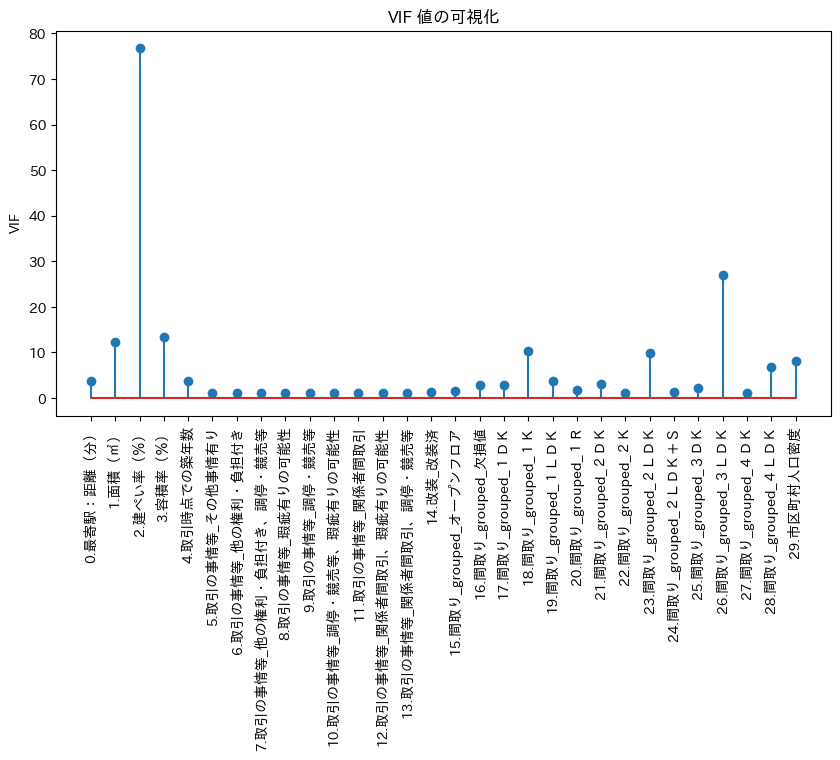

In [12]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(10, 5))
plt.stem(vif.index.astype(str) + "." + vif["変数名"], vif["VIF"])
plt.xticks(rotation=90)
plt.ylabel("VIF")
plt.title("VIF 値の可視化")
plt.show()

## 10以下で再学習

In [13]:
# VIF >= 10 の変数を抽出
high_vif_vars = vif[vif["VIF"] >= 10]["変数名"].tolist()

# 高VIF変数を除いた説明変数
X_reduced = X.drop(columns=high_vif_vars)

# データ分割
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, Y, test_size=0.2, random_state=42)

# モデル再学習
model_xgb_r = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae'
)

model_xgb_r.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)]
)

[0]	validation_0-mae:0.26229
[1]	validation_0-mae:0.25951
[2]	validation_0-mae:0.25359
[3]	validation_0-mae:0.24802
[4]	validation_0-mae:0.24291
[5]	validation_0-mae:0.23814
[6]	validation_0-mae:0.23380
[7]	validation_0-mae:0.23042
[8]	validation_0-mae:0.22660
[9]	validation_0-mae:0.22318
[10]	validation_0-mae:0.22156
[11]	validation_0-mae:0.21846
[12]	validation_0-mae:0.21561
[13]	validation_0-mae:0.21306
[14]	validation_0-mae:0.21176
[15]	validation_0-mae:0.20943
[16]	validation_0-mae:0.20731
[17]	validation_0-mae:0.20539
[18]	validation_0-mae:0.20368
[19]	validation_0-mae:0.20205
[20]	validation_0-mae:0.20051
[21]	validation_0-mae:0.19967
[22]	validation_0-mae:0.19845
[23]	validation_0-mae:0.19773
[24]	validation_0-mae:0.19701
[25]	validation_0-mae:0.19582
[26]	validation_0-mae:0.19513
[27]	validation_0-mae:0.19408
[28]	validation_0-mae:0.19315
[29]	validation_0-mae:0.19289
[30]	validation_0-mae:0.19240
[31]	validation_0-mae:0.19154
[32]	validation_0-mae:0.19119
[33]	validation_0-ma

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


In [14]:
# 予測
y_pred_r = model_xgb_r.predict(X_test_r)

# 評価指標
mae_r = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"[VIF>=10除外後] MAE: {mae_r:.4f}")
print(f"[VIF>=10除外後] RMSE: {rmse_r:.4f}")

[VIF>=10除外後] MAE: 0.1606
[VIF>=10除外後] RMSE: 0.2234


## 20以下

In [15]:
# VIF >= 20 の変数を抽出
high_vif_vars = vif[vif["VIF"] >= 20]["変数名"].tolist()

# 高VIF変数を除いた説明変数
X_reduced = X.drop(columns=high_vif_vars)

# データ分割
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, Y, test_size=0.2, random_state=42)

# モデル再学習
model_xgb_r2 = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae'
)

model_xgb_r2.fit(
    X_train_r, y_train_r,
    eval_set=[(X_test_r, y_test_r)]
)

[0]	validation_0-mae:0.26016
[1]	validation_0-mae:0.25196
[2]	validation_0-mae:0.24606
[3]	validation_0-mae:0.24224
[4]	validation_0-mae:0.23691
[5]	validation_0-mae:0.23337
[6]	validation_0-mae:0.22818
[7]	validation_0-mae:0.22182
[8]	validation_0-mae:0.21586
[9]	validation_0-mae:0.21026
[10]	validation_0-mae:0.20603
[11]	validation_0-mae:0.20156
[12]	validation_0-mae:0.19682
[13]	validation_0-mae:0.19243
[14]	validation_0-mae:0.18921
[15]	validation_0-mae:0.18528
[16]	validation_0-mae:0.18166
[17]	validation_0-mae:0.17977
[18]	validation_0-mae:0.17645
[19]	validation_0-mae:0.17336
[20]	validation_0-mae:0.17044
[21]	validation_0-mae:0.16774
[22]	validation_0-mae:0.16546
[23]	validation_0-mae:0.16365
[24]	validation_0-mae:0.16163
[25]	validation_0-mae:0.15972
[26]	validation_0-mae:0.15770
[27]	validation_0-mae:0.15658
[28]	validation_0-mae:0.15544
[29]	validation_0-mae:0.15373
[30]	validation_0-mae:0.15207
[31]	validation_0-mae:0.15055
[32]	validation_0-mae:0.14910
[33]	validation_0-ma

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


In [16]:

# 予測
y_pred_r2 = model_xgb_r2.predict(X_test_r)

# 評価指標
mae_r2 = mean_absolute_error(y_test_r, y_pred_r2)
rmse_r2 = np.sqrt(mean_squared_error(y_test_r, y_pred_r2))

print(f"[VIF>=20除外後] MAE: {mae_r2:.4f}")
print(f"[VIF>=20除外後] RMSE: {rmse_r2:.4f}")


[VIF>=20除外後] MAE: 0.1054
[VIF>=20除外後] RMSE: 0.1551


# カテゴリ変数をラベル化

In [ ]:

# --- 説明変数・目的変数のセット ---
X = df[['市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称','最寄駅：距離（分）', '面積（㎡）',  '建ぺい率（％）', '容積率（％）',
        '取引時点での築年数', '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き',
        '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
        '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
        '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性',
        '取引の事情等_関係者間取引、調停・競売等', '改装_改装済', '間取り_grouped_オープンフロア',
        '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
        '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
        '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
        '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
        '間取り_grouped_４ＬＤＫ','人口密度','市区町村人口密度']]

Y = df['取引価格（総額）_log']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import numpy as np

# --- カテゴリ変数の数値化 ---
categorical_features = ['都道府県名', '市区町村名', '地区名', '最寄駅：名称']

# Xをコピー（元データを変更しないため）
X_encoded = X.copy()

# Label Encoding
label_encoders = {}
for col in categorical_features:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

print(f"✓ カテゴリ変数を数値化しました")
print(f"特徴量数: {X_encoded.shape[1]}")

# --- データ分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# XGBoost モデル構築
model_xgb = XGBRegressor(
    objective='reg:squarederror',  # 回帰タスク
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae'
)

# 学習
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)


[0]	validation_0-mae:0.26225
[1]	validation_0-mae:0.25450
[2]	validation_0-mae:0.24655
[3]	validation_0-mae:0.24038
[4]	validation_0-mae:0.23823
[5]	validation_0-mae:0.23124
[6]	validation_0-mae:0.22467
[7]	validation_0-mae:0.21860
[8]	validation_0-mae:0.21293
[9]	validation_0-mae:0.20749
[10]	validation_0-mae:0.20346
[11]	validation_0-mae:0.19859
[12]	validation_0-mae:0.19409
[13]	validation_0-mae:0.18998
[14]	validation_0-mae:0.18785
[15]	validation_0-mae:0.18395
[16]	validation_0-mae:0.18035
[17]	validation_0-mae:0.17852
[18]	validation_0-mae:0.17548
[19]	validation_0-mae:0.17243
[20]	validation_0-mae:0.16953
[21]	validation_0-mae:0.16690
[22]	validation_0-mae:0.16441
[23]	validation_0-mae:0.16212
[24]	validation_0-mae:0.16098
[25]	validation_0-mae:0.15889
[26]	validation_0-mae:0.15696
[27]	validation_0-mae:0.15520
[28]	validation_0-mae:0.15354
[29]	validation_0-mae:0.15194
[30]	validation_0-mae:0.15050
[31]	validation_0-mae:0.14931
[32]	validation_0-mae:0.14802
[33]	validation_0-ma

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mae'


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 予測
y_pred = model_xgb.predict(X_test)

# 評価指標
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1051
RMSE: 0.1548


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIFを計算
vif = pd.DataFrame()
vif["変数名"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 出力
display(vif)

,変数名,VIF
0,最寄駅：距離（分）,3.831447
1,面積（㎡）,12.290299
2,建ぺい率（％）,76.782029
3,容積率（％）,13.358468
4,取引時点での築年数,3.790501
5,取引の事情等_その他事情有り,1.000219
6,取引の事情等_他の権利・負担付き,1.000136
7,取引の事情等_他の権利・負担付き、調停・競売等,1.000017
8,取引の事情等_瑕疵有りの可能性,1.000191
9,取引の事情等_調停・競売等,1.038005


In [ ]:
import japanize_matplotlib

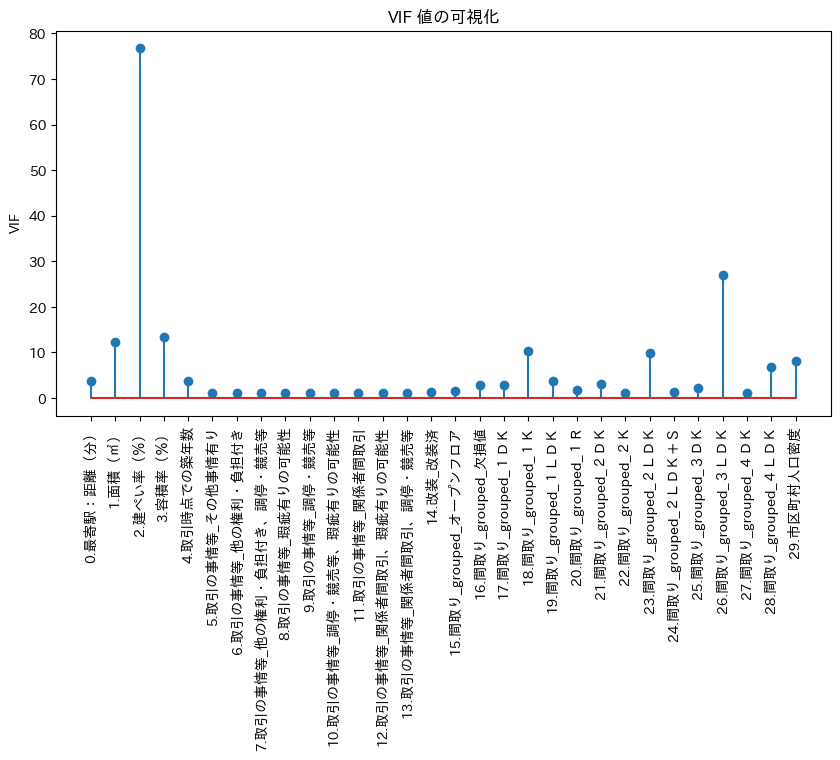

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(10, 5))
plt.stem(vif.index.astype(str) + "." + vif["変数名"], vif["VIF"])
plt.xticks(rotation=90)
plt.ylabel("VIF")
plt.title("VIF 値の可視化")
plt.show()